# Operaattorien mielikuvakartoitus PROC MDS -proseduurilla

## Yhteenveto

Teleoperaattorin markkinatutkimustiimi mittaa, kuinka samankaltaisina asiakkaat kokevat kahdeksan kilpailevaa matkapuhelinoperaattoria, ja käyttää **PROC MDS** -proseduuria kaksiulotteisen mielikuvakartan palauttamiseksi erilaisuusmatriisista. Kaksi piilevää ulottuvuutta — verkon laatu ja hinta/arvo — on tarkoituksella rakennettu vaihtelemaan *toisistaan riippumatta*, joten palautettu kartta on aidosti kaksiulotteinen: se näyttää, mitkä brändit koetaan toistensa korvaajiksi, mitkä asemoituvat selvästi erilleen, ja kuinka hyvin kaksi ulottuvuutta tiivistää kilpailutilanteen.

## Tietolähteet

| Aineisto | Rivit | Avainmuuttujat | Kuvaus |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (yksi per operaattori) | `Carrier` (tunnus), `D1`-`D8` | Neliömäinen symmetrinen matriisi koetuista erilaisuuksista 8 matkapuhelinoperaattorin välillä, asteikolla 0-10 (0 = koettu samanlaiseksi, suurempi = erilaisempi). Luotu piilevistä 2-ulotteisista brändipositioista kahdella *riippumattomalla* akselilla (verkon laatu ja hinta/arvo) sekä kyselykohinasta funktiolla `rand('NORMAL')`. Diagonaali on 0. |

# Operaattorien mielikuvakartoitus PROC MDS -proseduurilla

Telealan markkinatutkimustiimit pyytävät säännöllisesti kyselypaneeleja arvioimaan, kuinka *samankaltaisilta* tai *erilaisilta* kilpailevat operaattorit tuntuvat. Nämä parittaiset arviot muodostavat **läheisyysmatriisin**, jolla ei ole luonnollista koordinaatistoa - mutta **moniulotteinen skaalaus (MDS)** voi palauttaa matalaulotteisen kartan, jossa kahden brändin välinen etäisyys toistaa niiden koetun erilaisuuden.

Tässä muistikirjassa:

1. Synteesimme realistisen 8 operaattorin erilaisuusmatriisin kahdesta *riippumattomasta* positiointiakselista (verkon laatu ja hinta/arvo).
2. Sovitamme kaksiulotteisen metrisen MDS-mallin `PROC MDS`:llä.
3. Luemme palautetut koordinaatit ja sovituksen huonouden, ja piirrämme sitten mielikuvakartan palautetuista koordinaateista arvioidaksemme, kuinka hyvin kaksi ulottuvuutta selittää kilpailutilanteen.

## Vaihe 1 - Synteettisen erilaisuusmatriisin rakentaminen

Sijoitamme jokaisen operaattorin *todelliseen* piilevään positioon kahdella **riippumattomalla** akselilla:

- **Verkon laatu -akseli** - valtakunnalliset premium-operaattorit saavat korkeat pisteet; edulliset MVNO-operaattorit matalat.
- **Hinta/arvo-akseli** - arvo-/prepaid-brändit saavat korkeat pisteet; premium-hintaiset brändit matalat.

Ratkaisevaa on, että kaksi akselia ovat korreloimattomia kahdeksan brändin kesken: laadukas operaattori voi olla joko premium-hintainen (NorthStar) tai aggressiivisesti arvohintainen (BluePeak), ja edullisen laadun operaattori voi sijaita hinnaltaan missä tahansa. Juuri tämä riippumattomuus tekee palautetusta kartasta aidosti kaksiulotteisen sen sijaan, että se litistyisi yhdelle suoralle.

Kahden operaattorin koettu erilaisuus on niiden piilevien positioiden euklidinen etäisyys, uudelleenskaalattuna 0-10-kyselyasteikolle ja häirittynä symmetrisellä kyselykohinalla. `PROC MDS` odottaa **neliömäistä matriisia**: yksi havainto per kohde ja yksi numeerinen sarake per kohde, rivijärjestyksen vastatessa sarakejärjestystä. Kirjoitamme sarakkeet `D1`-`D8` sekä `Carrier`-nimikkeen, ja pakotamme matriisin symmetriseksi nollediagonaalilla.

In [1]:
TIEDOT carrier_dissim;
    PITUUS Carrier $ 12;
    CALL streaminit(20240517);

    /* Todelliset 2-ulotteiset piilevat positiot kahdella RIIPPUMATTOMALLA
       akselilla: qx = verkon laatu, px = hinta/arvo (korrelaatio ~ 0). */
    TAULUKKO qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    TAULUKKO px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);

    /* Symmetrinen kohinamatriisi, luotu kerran, nolladiagonaali */
    TAULUKKO e[8,8] _temporary_;
    TEE i = 1 ASTI 8;
        e[i,i] = 0;
        TEE j = i+1 ASTI 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        LOPPU;
    LOPPU;

    /* Brandinimet annettu suoralla IF/ELSE-ketjulla taulukkohaun sijaan,
       jotta valtetaan moottorin tunnettu katkaisubugi kiinteaan merkkitaulukkoon
       alustettuna muilla kuin ASCII-arvoilla. Nama nimet ovat ASCII-brandinimia
       eika niita kaanneta (kuten oikeita yritysnimia ei yleensa kaanneta). */
    TAULUKKO d[8] D1-D8;
    TEE i = 1 ASTI 8;
        JOS i = 1 NIIN Carrier = 'NorthStar';
        MUUTEN JOS i = 2 NIIN Carrier = 'BluePeak';
        MUUTEN JOS i = 3 NIIN Carrier = 'Vertex';
        MUUTEN JOS i = 4 NIIN Carrier = 'MetroLink';
        MUUTEN JOS i = 5 NIIN Carrier = 'ValueCell';
        MUUTEN JOS i = 6 NIIN Carrier = 'ThriftMobile';
        MUUTEN JOS i = 7 NIIN Carrier = 'Centerline';
        MUUTEN Carrier = 'PennyWave';
        TEE j = 1 ASTI 8;
            DIST = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* uudelleenskaalaa piileva etaisyys 0-10 kyselyasteikolle */
            d[j] = round( MAX(0, MIN(10, DIST*0.85 + e[i,j])), 0.1);
        LOPPU;
        d[i] = 0;            /* brandi on identtinen itsensa kanssa */
        TULOSTE;
    LOPPU;

    SÄILYTÄ Carrier D1-D8;
SUORITA;

PROC PRINT TIEDOT=carrier_dissim noobs NIMIKE;
    NIMIKE Carrier = 'Operaattori';
    OTSIKKO 'Koettu erilaisuusmatriisi (0 = samanlainen, 10 = erilaisin)';
SUORITA;


                              Koettu erilaisuusmatriisi (0 = samanlainen, 10 = erilaisin)                               

 Operaattori   D1   D2   D3   D4   D5   D6   D7   D8
NorthStar       0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
BluePeak      3.5    0  2.5  2.9  5.9    6    2    5
Vertex        1.6  2.5    0  1.7  3.6  5.1  3.4    4
MetroLink     3.6  2.9  1.7    0  3.1  3.6  1.9    2
ValueCell     4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
ThriftMobile  6.1    6  5.1  3.6  1.8    0  5.3  2.3
Centerline    5.5    2  3.4  1.9  5.1  5.3    0  2.5
PennyWave     6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Vaihe 2 - Kaksiulotteisen metrisen MDS-mallin sovitus

Mallinnamme erilaisuudet tasolla `LEVEL=INTERVAL` (metrinen MDS, joka sallii additiivisen vakion), ulottuvuudella `DIM=2`, jotta tulos voidaan piirtää tasokartalle. Data on erilaisuuksia (oletus), tallennettuna täytenä `SQUARE`-matriisina.

Keskeiset lauseet ja valinnat:

- `VAR D1-D8` listaa kahdeksan saraketta, yhden per kohde.
- `ID Carrier` liittää brändinimet, jotta ne näkyvät tulosteessa ja `OUT=`-koordinaateissa.
- `OUT=` tallentaa kohteiden koordinaatit (pyydetty `OCONFIG`-valinnalla), ja `OUTFIT=` tallentaa sovituksen huonouden yhteenvedon.
- `PCONFIG`, `PFIT` ja `PFINAL` tulostavat koordinaatit, sovitustunnusluvut ja lopulliset parametriestimaatit.

Piirrämme mielikuvakartan itse Vaiheessa 3 palautetuista `OUT=`-koordinaateista, mikä antaa täyden hallinnan brändinimikkeisiin ja akseliskaalaukseen.

In [2]:
PROC MDS TIEDOT=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    MUUTTUJA D1-D8;
    id Carrier;
    OTSIKKO 'Kaksiulotteinen MDS-analyysi operaattorimielikuvista';
SUORITA;


                              Koettu erilaisuusmatriisi (0 = samanlainen, 10 = erilaisin)                               




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/51a44829-5fe8-4340-8bc8-7a0cc4aec446/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.67 seconds
  cpu   1.67 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/51a44829-5fe8-4340-8bc8-7a0cc4aec446/mds_fit.avro (2 rows, 3 columns).


## Vaihe 3 - Palautettujen koordinaattien poiminta ja kartan piirtäminen

`OCONFIG`-valinnalla `OUT=`-aineisto sisältää estimoidut kohteiden koordinaatit (yksi rivi per operaattori, yksi sarake per ulottuvuus). Tulostamme nämä koordinaatit ja sovituksen huonouden, ja piirrämme sitten `DIM2`:n suhteessa `DIM1`:een `PROC SGPLOT`:lla - merkiten jokaisen pisteen operaattorin nimellä - mielikuvakartan tuottamiseksi.

MDS-koordinaatit on määritelty vain rotaatiota, peilausta ja tasaista skaalausta myöten, joten akselien absoluuttiset etumerkit ovat mielivaltaisia; merkitystä on brändien *suhteellisella* geometrialla. Rotaation jälkeen toinen akseli seuraa verkon laatua ja toinen hinta/arvoa.

                                 Palautettu MDS-konfiguraatio (kohteiden koordinaatit)                                  

  Obs  _TYPE_        _NAME_           DIM1           DIM2
    1  CONFIG  NorthStar      2.8874230583  -1.8461705276
    2  CONFIG  BluePeak       -0.687559872  -2.8913969565
    3  CONFIG  Vertex         1.1117392105  -1.2431470382
    4  CONFIG  MetroLink     -0.4552922046  -0.0907948566
    5  CONFIG  ValueCell      1.6998640261   2.3061186021
    6  CONFIG  ThriftMobile  -0.1575406636   3.3768661059
    7  CONFIG  Centerline    -2.2391140787  -1.1789057517
    8  CONFIG  PennyWave     -2.1595194761   1.5674304226

                                        MDS-sovituksen poikkeamaluvun yhteenveto                                        

  Obs  _DIMENS_  _MATRIX_        CRITER
    1         2            1.8502928101
    2         2  MATRIX1   1.8502928101

                                        MDS-sovituksen poikkeamaluvun yhteenveto                                


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


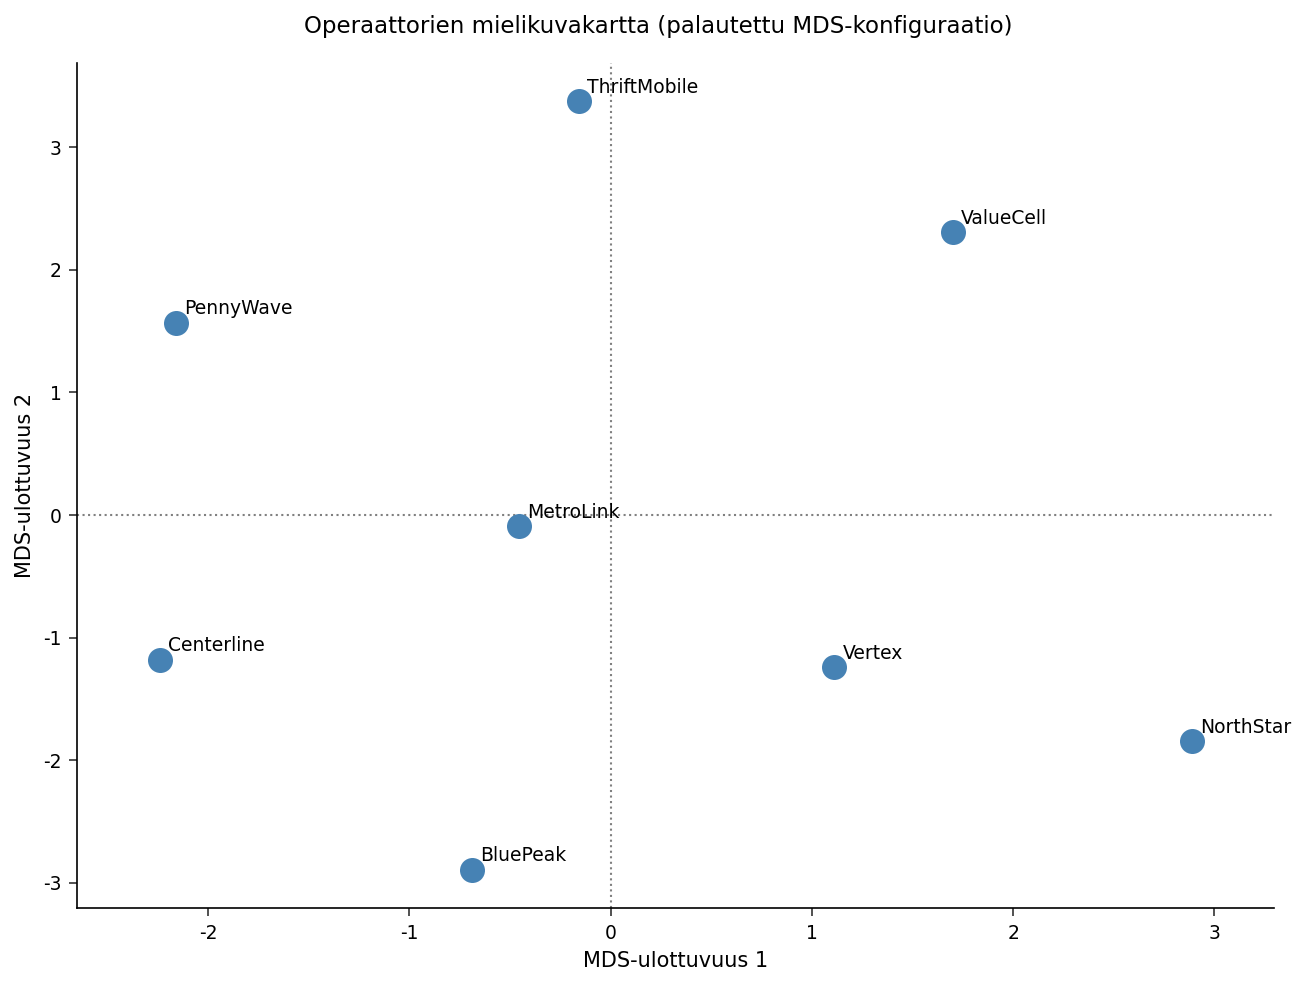

In [3]:
PROC PRINT TIEDOT=mds_out NIMIKE;
    NIMIKE Carrier = 'Operaattori';
    OTSIKKO 'Palautettu MDS-konfiguraatio (kohteiden koordinaatit)';
SUORITA;

PROC PRINT TIEDOT=mds_fit NIMIKE;
    OTSIKKO 'MDS-sovituksen poikkeamaluvun yhteenveto';
SUORITA;

/* Sailytamme konfiguraatiorivit ja annamme brandille selkean nimikesarakkeen,
   jotta SGPLOT voi tulostaa sen jokaisen pisteen viereen. */
TIEDOT mds_config;
    ASETA mds_out;
    MISSÄ _TYPE_ = 'CONFIG';
    PITUUS Brand $ 12;
    Brand = _NAME_;
    SÄILYTÄ Brand DIM1 DIM2;
SUORITA;

/* Piirramme mielikuvakartan palautetuista koordinaateista, merkiten
   jokaisen pisteen operaattorin nimella. */
PROC SGPLOT TIEDOT=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS NIMIKE='MDS-ulottuvuus 1';
    YAXIS NIMIKE='MDS-ulottuvuus 2';
    OTSIKKO 'Operaattorien mielikuvakartta (palautettu MDS-konfiguraatio)';
SUORITA;


## Vaihe 4 — Koettujen korvaajien järjestäminen

Käytännön tuotos bränditiimille on, jokaiselle operaattorille, se kilpailija, joka koetaan *samankaltaisimmaksi* (pienin diagonaalin ulkopuolinen erilaisuus). Muotoilemme matriisin pitkään muotoon ja poimimme lähimmän naapurin jokaiselle operaattorille — nämä parit ovat lähimmät korvaajat ja terävimmät kilpailu-uhat.

In [4]:
/* Etaisyystaulukko pitkassa muodossa: nimeamme jokaiselle operaattorille
   sen 8 rinnakkaista suhdetta muihin operaattoreihin (poislukien itsensa).
   Brandinimet IF/ELSE-ketjulla taulukkohaun sijaan (ks. huomautus edella). */
TIEDOT dissim_long;
    ASETA carrier_dissim;
    PITUUS OTHER $ 12;
    TAULUKKO d[8] D1-D8;
    TEE j = 1 ASTI 8;
        JOS j = 1 NIIN OTHER = 'NorthStar';
        MUUTEN JOS j = 2 NIIN OTHER = 'BluePeak';
        MUUTEN JOS j = 3 NIIN OTHER = 'Vertex';
        MUUTEN JOS j = 4 NIIN OTHER = 'MetroLink';
        MUUTEN JOS j = 5 NIIN OTHER = 'ValueCell';
        MUUTEN JOS j = 6 NIIN OTHER = 'ThriftMobile';
        MUUTEN JOS j = 7 NIIN OTHER = 'Centerline';
        MUUTEN OTHER = 'PennyWave';
        Dissimilarity = d[j];
        JOS Carrier ne OTHER NIIN TULOSTE;
    LOPPU;
    SÄILYTÄ Carrier OTHER Dissimilarity;
SUORITA;

PROC SORT TIEDOT=dissim_long;
    MUKAAN Carrier Dissimilarity;
SUORITA;

TIEDOT nearest;
    ASETA dissim_long;
    MUKAAN Carrier Dissimilarity;
    JOS first.Carrier;
SUORITA;

PROC PRINT TIEDOT=nearest noobs NIMIKE;
    NIMIKE Carrier = 'Operaattori' OTHER = 'Lähin koettu korvaaja'
          Dissimilarity = 'Erilaisuus';
    OTSIKKO 'Jokainen operaattori ja sen lähin koettu korvaaja';
SUORITA;


                                   Jokainen operaattori ja sen lähin koettu korvaaja                                    

 Operaattori   Lähin koettu korvaaja  Erilaisuus
BluePeak      Centerline                       2
Centerline    MetroLink                      1.9
MetroLink     Vertex                         1.7
NorthStar     Vertex                         1.6
PennyWave     MetroLink                        2
ThriftMobile  ValueCell                      1.8
ValueCell     ThriftMobile                   1.8
Vertex        NorthStar                      1.6




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Tulosten tulkinta

Koska erilaisuudet luotiin aidosta kaksiulotteisesta piilevästä rakenteesta (verkon laatu ja hinta/arvo, rakennettu vaihtelemaan riippumattomasti) sekä vaatimattomasta kyselykohinasta, `PROC MDS` palauttaa siistin kaksiulotteisen konfiguraation. Sovituksen huonouskriteeri asettuu noin arvoon 1,85 - tiukka sovitus, joka vahvistaa, että kaksi ulottuvuutta selittää lähes kaiken koetusta rakenteesta.

Palautetun kartan tulkinta (akselit on määritelty vain rotaatiota, peilausta ja skaalaa myöten, joten tulkitsemme suuntia emme absoluuttisia etumerkkejä):

- **Toinen akseli seuraa verkon laatua** - se erottaa valtakunnalliset premium-brändit (NorthStar, Vertex, BluePeak) edullisista MVNO-operaattoreista (ThriftMobile, PennyWave, ValueCell), MetroLinkin ja Centerlinen asettuessa keskelle.
- **Toinen akseli seuraa hinta/arvoa** - se erottaa aggressiivisesti arvohintaisen positioinnin premium-hintaisesta, minkä vuoksi laadukas brändi kuten BluePeak sijoittuu kauas yhtä laadukkaasta NorthStarista: ne jakavat verkon maineen mutta kilpailevat hyvin erilaisilla hintatarinoilla.
- Kartta ei näytä yhtä hallitsevaa gradienttia: brändit levittäytyvät kaikkiin neljään neljännekseen, joten kilpailutilanne on aidosti kaksiulotteinen eikä yksi premium-budjetti-jana.

**Lähimmän korvaajan taulukko** muuttaa kartan toimintalistaksi. Jokaisen operaattorin läheisin koettu kilpailija on kartalla vieressä oleva brändi - NorthStar ja Vertex ankkuroivat premium-kulman, ValueCell ja ThriftMobile muodostavat parin arvokulmassa, ja MetroLink näyttäytyy lähimpänä korvaajana useille keskihintaisille brändeille, koska se sijaitsee kartan keskellä. Tiiviit parit merkitsevät suoria kilpailijoita; klustereiden väliset tyhjät alueet korostavat vapaata positiointia, johon haastajabrändi voisi tähdätä.